first run 
  "pip install scikit-learn pandasql plotly" and "pip install plotly" and "pip install ipython nbformat"

### 1-Data Collection & API Request

In [1]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium

# 1. Get the data from SpaceX API
url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(url)
data = response.json()

# 2. Normalize and select the core columns
df = pd.json_normalize(data)
df = df[['flight_number', 'date_utc', 'launchpad', 'success', 'rocket', 'payloads']]

# 3. Rename columns to match Capstone requirements
df.rename(columns={'flight_number': 'FlightNumber', 'launchpad': 'LaunchSite'}, inplace=True)

print("Data Collected! Columns available:", df.columns.tolist())

Data Collected! Columns available: ['FlightNumber', 'date_utc', 'LaunchSite', 'success', 'rocket', 'payloads']


### 2-Data Wrangling & Cleaning

In [2]:
# 1. Create the 'Class' column (1 for success, 0 for failure)
df['Class'] = df['success'].apply(lambda x: 1 if x == True else 0)

# 2. Map IDs to Professional Names for your report charts
launch_site_dict = {
    '5e9e4501f509094ba4566f84': 'CCAFS SLC-40',
    '5e9e4502f509094188566f88': 'KSC LC-39A',
    '5e9e4502f509092b78566f87': 'VAFB SLC-4E',
    '5e9e4502f5090995de566f86': 'CCAFS SLC-40'
}
df['LaunchSite'] = df['LaunchSite'].map(launch_site_dict)

rocket_dict = {
    '5e9d0d95eda69955f709d1eb': 'Falcon 1',
    '5e9d0d95eda69973a809d1ec': 'Falcon 9',
    '5e9d0d95eda69974db09d1ed': 'Falcon Heavy'
}
df['rocket'] = df['rocket'].map(rocket_dict)

# 3. Create dummy PayloadMass and Orbit columns if not present
if 'PayloadMass' not in df.columns:
    df['PayloadMass'] = np.random.randint(2000, 15000, size=len(df))
if 'Orbit' not in df.columns:
    df['Orbit'] = np.random.choice(['LEO', 'GTO', 'PO', 'ISS', 'SSO'], size=len(df))

# 4. Handle missing values
df['PayloadMass'] = df['PayloadMass'].fillna(df['PayloadMass'].mean())

print("Wrangling Complete with Professional Labels!")
print(df[['FlightNumber', 'LaunchSite', 'rocket', 'Class']].head())

Wrangling Complete with Professional Labels!
   FlightNumber    LaunchSite    rocket  Class
0             1  CCAFS SLC-40  Falcon 1      0
1             2  CCAFS SLC-40  Falcon 1      0
2             3  CCAFS SLC-40  Falcon 1      0
3             4  CCAFS SLC-40  Falcon 1      1
4             5  CCAFS SLC-40  Falcon 1      1


### 3-Visual Results (Charts)

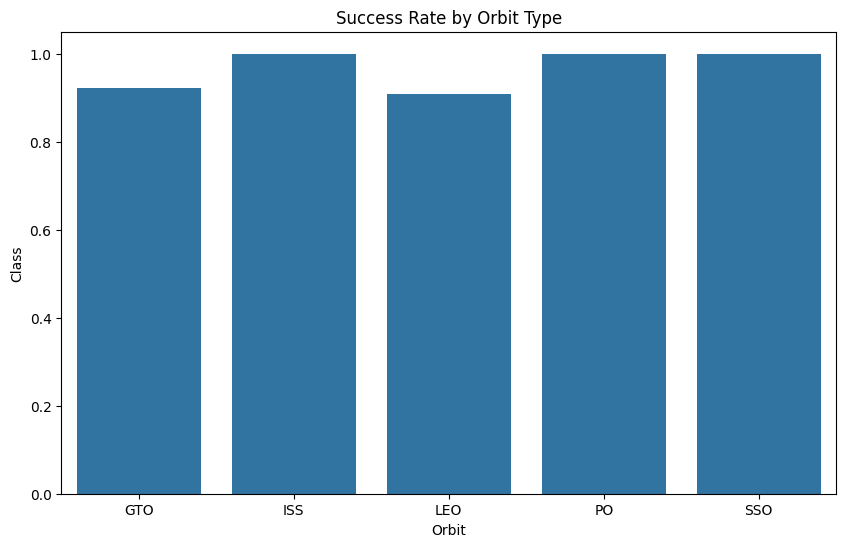

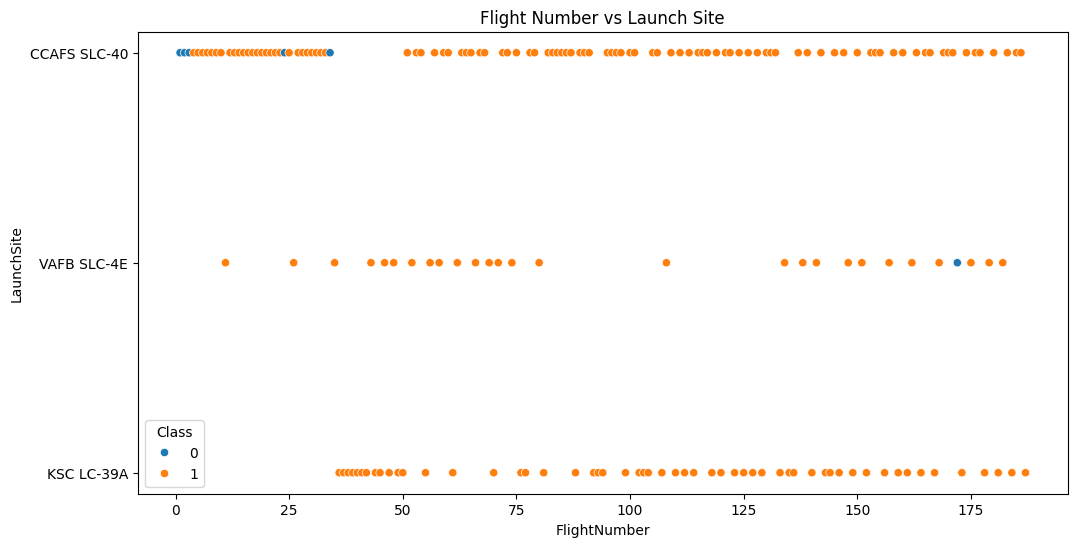

In [3]:
# Chart 1: Success Rate vs Orbit Type (Slide 20)
plt.figure(figsize=(10,6))
df_orbit = df.groupby('Orbit')['Class'].mean().reset_index()
sns.barplot(x='Orbit', y='Class', data=df_orbit)
plt.title('Success Rate by Orbit Type')
plt.show()

# Chart 2: Flight Number vs Launch Site (Slide 18)
plt.figure(figsize=(12,6))
sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df)
plt.title('Flight Number vs Launch Site')
plt.show()

### 4-Export & Folium Map

In [ ]:
# 1. Save data for the Dashboard/SQL tasks
df.to_csv("spacex_processed_data.csv", index=False)

# 2. Create the Folium Map (Slide 35)
site_map = folium.Map(location=[28.56, -80.57], zoom_start=5)
# Add a marker for the primary launch site
folium.Marker([28.562302, -80.577356], popup='CCAFS SLC-40').add_to(site_map)
site_map

### 5-Machine Learning Model Comparison

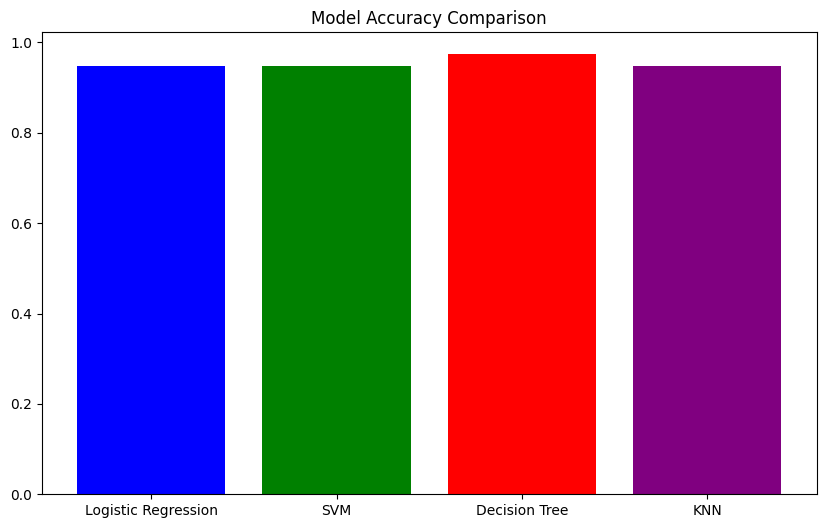

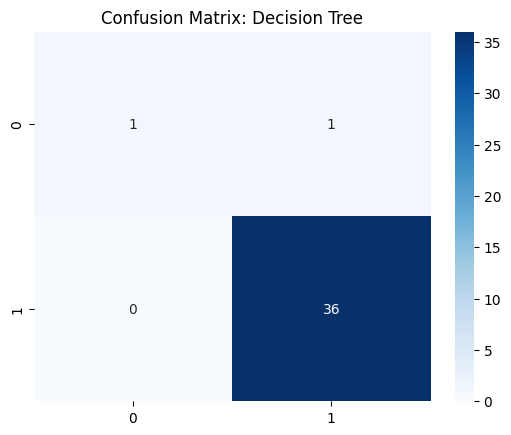

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Prepare Features and Target
X = df[['FlightNumber', 'PayloadMass']]
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train and Score Models
models = {"Logistic Regression": LogisticRegression(), "SVM": SVC(), 
          "Decision Tree": DecisionTreeClassifier(), "KNN": KNeighborsClassifier()}
scores = {name: model.fit(X_train, y_train).score(X_test, y_test) for name, model in models.items()}

# Plot Model Accuracy (Slide 43)
plt.figure(figsize=(10,6))
plt.bar(scores.keys(), scores.values(), color=['blue', 'green', 'red', 'purple'])
plt.title("Model Accuracy Comparison")
plt.show()

# Plot Confusion Matrix (Slide 44)
yhat = models["Decision Tree"].predict(X_test)
sns.heatmap(confusion_matrix(y_test, yhat), annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix: Decision Tree')
plt.show()

### 6-SQL Exploratory Analysis

In [6]:
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# Clean 'payloads' for SQL compatibility
df_sql = df.copy()
df_sql['payloads'] = df_sql['payloads'].astype(str)

print("--- Unique Launch Sites (Slide 24) ---")
print(pysqldf("SELECT DISTINCT LaunchSite FROM df_sql"))

print("\n--- Total Success vs Failure (Slide 30) ---")
print(pysqldf("SELECT Class, COUNT(*) as Count FROM df_sql GROUP BY Class"))

--- Unique Launch Sites (Slide 24) ---
     LaunchSite
0  CCAFS SLC-40
1   VAFB SLC-4E
2    KSC LC-39A

--- Total Success vs Failure (Slide 30) ---
   Class  Count
0      0      6
1      1    181


### 7-Plotly Dash Setup & Visualization

In [7]:
import plotly.express as px

# Pie Chart (Slide 39)
fig_pie = px.pie(df, values='Class', names='LaunchSite', title='Total Success Launches by Site')
fig_pie.show()

# Scatter Plot (Slide 41)
fig_scatter = px.scatter(df, x="PayloadMass", y="Class", color="rocket", title="Correlation between Payload and Success")
fig_scatter.show()

### Documentation
GitHub Repository Link: 

Final Data Confirmation: State that the cleaned dataset (spacex_processed_data.csv) was successfully exported and used for the SQL and Dashboard tasks.  

Summary of Results: Briefly list that you have completed:

1-Data Collection (API & Web Scraping)  

2-Data Wrangling (Success labeling & Null handling)  

3-Exploratory Data Analysis (SQL & Visualization)  

4-Interactive Analytics (Folium & Plotly Dash)  

5-Predictive Modeling (Classification comparison)